<a href="https://colab.research.google.com/github/pabloecheg/Unsupervised-Learning/blob/main/RETO_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive') # Conexión con mi unidad en Google Drive

Mounted at /content/drive


In [ ]:
import pandas as pd # manejo de Data Frame en Python
pd.set_option('display.max_columns', 50) # Aumenta el número de columnas
import numpy as np
# Librería de gráficos
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

In [ ]:
data= pd.read_csv("/content/drive/MyDrive/APRENDIZAJE NO SUPERVISADO/marketing_campaign.csv" ,sep= "\t")

In [ ]:
data

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,13-06-2013,46,709,43,182,42,118,247,2,9,3,4,5,0,0,0,0,0,0,3,11,0
2236,4001,1946,PhD,Together,64014.0,2,1,10-06-2014,56,406,0,30,0,0,8,7,8,2,5,7,0,0,0,1,0,0,3,11,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,25-01-2014,91,908,48,217,32,12,24,1,2,3,13,6,0,1,0,0,0,0,3,11,0
2238,8235,1956,Master,Together,69245.0,0,1,24-01-2014,8,428,30,214,80,30,61,2,6,5,10,3,0,0,0,0,0,0,3,11,0


In [ ]:
data= data.dropna() # Elimina registros que contengan al menos un NA

In [ ]:
#Sumar columna por columna para ver el numero total de campañas aceptadas
data["Numcmp"] = data['AcceptedCmp1'] +data['AcceptedCmp2'] +data['AcceptedCmp3'] +data['AcceptedCmp4'] +data['AcceptedCmp5']
data["Numcmp"]

0       0
1       0
2       0
3       0
4       0
       ..
2235    0
2236    1
2237    1
2238    0
2239    0
Name: Numcmp, Length: 2216, dtype: int64

In [ ]:
#Crear un nuevo conjunto de datos eliminando las variables que no necesito
data1 = data.drop(labels=["Year_Birth", "ID", "AcceptedCmp1", "AcceptedCmp2", "AcceptedCmp3", "AcceptedCmp4", "AcceptedCmp5", 'Response'], axis=1)
data1

,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Z_CostContact,Z_Revenue,Numcmp
0,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,546,172,88,88,3,8,10,4,7,0,3,11,0
1,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,6,2,1,6,2,1,1,2,5,0,3,11,0
2,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,127,111,21,42,1,8,2,10,4,0,3,11,0
3,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,20,10,3,5,2,2,0,4,6,0,3,11,0
4,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,118,46,27,15,5,5,3,6,5,0,3,11,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,Graduation,Married,61223.0,0,1,13-06-2013,46,709,43,182,42,118,247,2,9,3,4,5,0,3,11,0
2236,PhD,Together,64014.0,2,1,10-06-2014,56,406,0,30,0,0,8,7,8,2,5,7,0,3,11,1
2237,Graduation,Divorced,56981.0,0,0,25-01-2014,91,908,48,217,32,12,24,1,2,3,13,6,0,3,11,1
2238,Master,Together,69245.0,0,1,24-01-2014,8,428,30,214,80,30,61,2,6,5,10,3,0,3,11,0


In [ ]:
#crear nueva variable que dice el numero total de hijos (Sean niños o adolescentes)
data1['NumKids']= data1['Kidhome'] + data1['Teenhome']
data1['NumKids']

0       0
1       2
2       0
3       1
4       1
       ..
2235    1
2236    3
2237    0
2238    1
2239    2
Name: NumKids, Length: 2216, dtype: int64

In [ ]:
#Filtrar Data1 y crear valores para indicar si tiene hijos o no
data1.loc[data1["NumKids"]== 0, "Tiene Hijos"] ="No"
data1.loc[data1["NumKids"]> 0, "Tiene Hijos"] ="Si"

In [ ]:
campañas_hijos = data1.groupby('Tiene Hijos')['Numcmp'].value_counts(normalize=True)
print(campañas_hijos)

Tiene Hijos  Numcmp
No           0         0.639810
             1         0.206951
             2         0.082148
             3         0.056872
             4         0.014218
Si           0         0.854075
             1         0.121289
             2         0.018320
             3         0.005054
             4         0.001263
Name: proportion, dtype: float64


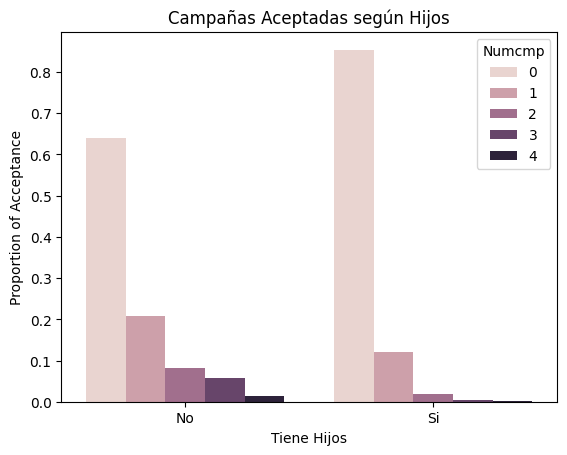

In [ ]:
tabla_frecuencia_relacion= data1.groupby('Tiene Hijos')['Numcmp'].value_counts(normalize=True)
sns.barplot(data=tabla_frecuencia_relacion.reset_index(), x='Tiene Hijos', y='proportion', hue='Numcmp')
plt.ylabel("Proportion of Acceptance")
plt.title("Campañas Aceptadas Según Hijos")
plt.show()

Por lo que podemos observar en el grafico, los clientes que tienen hijos son mucho menos probables a aceptar campañas.

Mas del 80% de los clientes que tienen hijos son propensos a no aceptar ninguna de las campañas, mientras que alrededor del 40% de clientes sin hijos aceptan almenos una campaña.

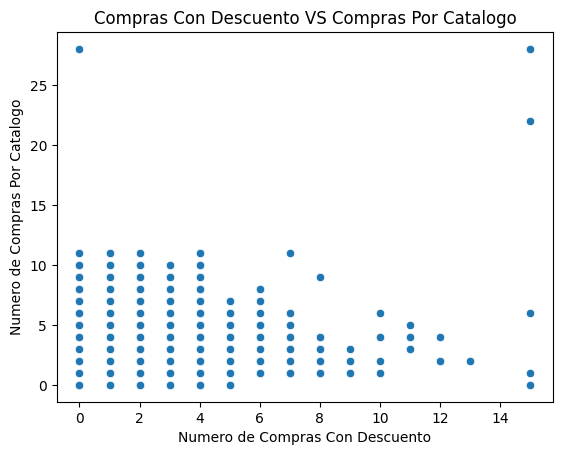

In [ ]:
sns.scatterplot(data=data1, x='NumDealsPurchases', y='NumCatalogPurchases')
plt.xlabel("Numero de Compras Con Descuento")
plt.ylabel("Numero de Compras Por Catalogo")
plt.title("Compras Con Descuento VS Compras Por Catalogo")
plt.show()

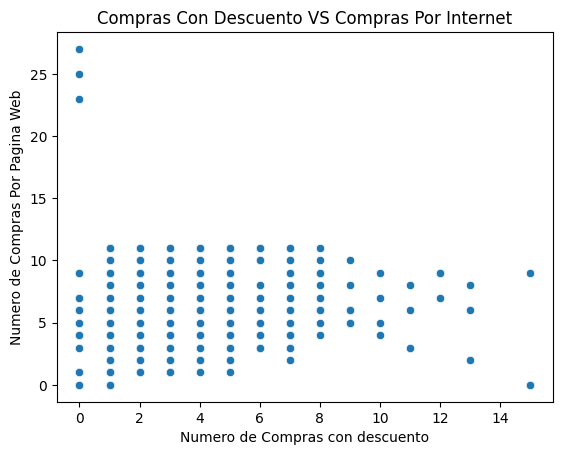

In [ ]:
sns.scatterplot(data=data1, x='NumDealsPurchases', y='NumWebPurchases')
plt.xlabel("Numero de Compras Con Descuento")
plt.ylabel("Numero de Compras Por Pagina Web")
plt.title("Compras Con Descuento VS Compras Por Internet")
plt.show()

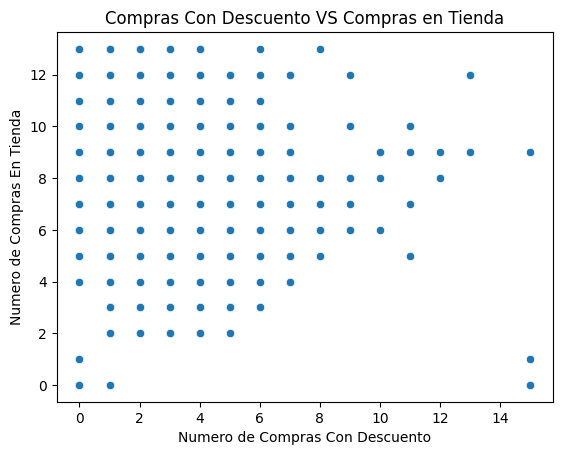

In [ ]:
sns.scatterplot(data=data1, x='NumDealsPurchases', y='NumStorePurchases')
plt.xlabel("Numero de Compras Con Descuento")
plt.ylabel("Numero de Compras En Tienda")
plt.title("Compras Con Descuento VS Compras en Tienda")
plt.show()

<Axes: xlabel='NumDealsPurchases', ylabel='NumWebPurchases'>

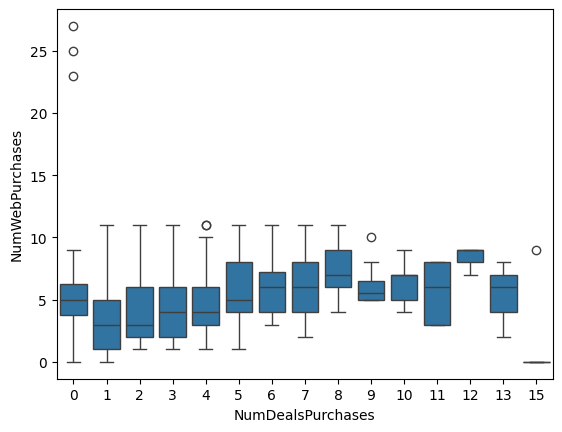

In [ ]:
sns.boxplot(data=data1, x='NumDealsPurchases', y='NumWebPurchases')

Por lo visto en los gráficos, no hay una coorelacion clara entre el numero de compras (independientemente de la modalidad) y el numero de compras con descuento.

Gracias a esto podemos inferir que la estrategia de ventas no es la mas adecuada, ya que lo normal sería ver un incremento en las ventas al implementar los descuentos.